# BBS Customer & Marketing Analytics
## Team Assignment 1 — 2026
### What Makes an Influencer Post Work?

**Team members:** Giulia Lorelli, Francesco Gambera, Romain Derguini, Israa Ismail, Iolanda Costa  

---
## Setup — Libraries and Data Loading

In [1]:
!pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [5]:
# ── Data Loading ─────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # select Team_Assignment_1_Data_2026.csv
df = pd.read_csv('Team_Assignment_1_Data_2026.csv', sep=';')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Saving Team_Assignment_1_Data_2026.csv to Team_Assignment_1_Data_2026.csv
Dataset loaded: 600 rows, 26 columns


,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
0,1,26,-0.6817,0,0,0,1,1,0,0,...,0,1,1,24.2,1,669.4,5,7.90,1,42
1,2,29,-0.5492,0,0,0,0,0,0,0,...,1,1,0,26.0,0,44.8,5,9.55,0,48
2,3,25,-0.7258,0,0,0,0,0,0,0,...,1,1,0,18.6,0,45.3,4,10.57,0,95
3,4,17,-10.7920,1,1,0,0,0,0,0,...,1,1,0,23.0,0,45.9,2,9.14,1,28
4,5,40,-0.0632,0,0,0,0,0,0,0,...,0,1,1,31.8,0,19.1,4,6.63,0,10


---
## Q0 — Data Preparation

In [6]:
# ── General inspection ───────────────────────────────────────────────────────
print("--- Missing values ---")
print(df.isnull().sum())
print()
print("--- Descriptive statistics ---")
df.describe()

--- Missing values ---
Post_ID                            0
Caption_Length                     0
ZCaption_Length                    0
Topic_Prod_Features                0
Topic_Prod_Features_Positive       0
Topic_Prod_Features_Negative       0
Topic_Promo_Deal                   0
Topic_Promo_Deal_Positive          0
Topic_Promo_Deal_Negative          0
Topic_Lifestyle_Values             0
Topic_Lifestyle_Values_Positive    0
Topic_Lifestyle_Values_Negative    0
Topic_CTA                          0
Topic_CTA_Positive                 0
Topic_CTA_Negative                 0
Product_Category                   0
Platform                           0
Post_Type                          0
Influencer_Gender                  0
Influencer_Age                     0
Influencer_Tier                    0
Follower_Count_K                   0
Caption_Sentiment                  0
Engagement_Rate                    0
Click_Through                      0
Comment_Count                      0
dtype: int64

-

,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,41.431667,0.972911,0.541667,0.431667,0.066667,0.343333,0.301667,0.013333,0.436667,...,0.496667,0.548333,0.348333,27.061167,0.42000,184.040167,3.705000,7.635767,0.496667,48.710000
std,173.349358,22.656733,8.480340,0.498677,0.495722,0.249652,0.475218,0.459364,0.114793,0.496386,...,0.500406,0.498074,0.476840,4.687682,0.49397,229.175503,1.086251,2.468081,0.500406,44.899694
min,1.000000,8.000000,-14.768000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,18.000000,0.00000,5.000000,1.000000,0.300000,0.000000,2.000000
25%,150.750000,25.000000,-0.725800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,23.800000,0.00000,23.600000,3.000000,6.130000,0.000000,19.000000
50%,300.500000,37.000000,-0.195800,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,27.000000,0.00000,42.450000,4.000000,7.695000,0.000000,35.000000
75%,450.250000,53.000000,0.511000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,30.300000,1.00000,328.550000,5.000000,9.305000,1.000000,64.000000
max,600.000000,199.000000,69.604000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,42.700000,1.00000,794.100000,5.000000,15.080000,1.000000,278.000000


### In the next cell we work on **dummies variables.**
`Product_Category` has 3 nominal levels: `Beauty & Skincare` (0), `Fashion & Apparel` (1), `Tech & Gadgets `(2).
Since it's a categorical variable, we cannot use it as a number in regression.

We create 2 binary dummy variables (one per non-reference category).

Beauty & Skincare is dropped as the reference group, its effect is captured by the intercept.

All other categories will be interpreted relative to Beauty & Skincare.

3 categories → 2 dummies; reference = Beauty & Skincare (0)

In [7]:
# ── Dummy coding: Product_Category ───────────────────────────────────────────
# 3 categories → 2 dummies; reference = Beauty & Skincare (0)
dummies = pd.get_dummies(df['Product_Category'], prefix='Cat', drop_first=False)
dummies.columns = ['Cat_Beauty', 'Cat_Fashion', 'Cat_Tech']
dummies = dummies[['Cat_Fashion', 'Cat_Tech']]  # drop reference
df = pd.concat([df, dummies], axis=1)

print("Dummies created: Cat_Fashion, Cat_Tech (ref: Beauty & Skincare)")
print(df[['Product_Category', 'Cat_Fashion', 'Cat_Tech']].value_counts().sort_index())

Dummies created: Cat_Fashion, Cat_Tech (ref: Beauty & Skincare)
Product_Category  Cat_Fashion  Cat_Tech
0                 False        False       221
1                 True         False       231
2                 False        True        148
Name: count, dtype: int64


### The next cell visualizes the three dependent variables we are predicting in our models.
1. **Engagement Rate:** The percentage of the influencer's audience that engaged with the post.
2. **Click-Through:** Whether the post successfully drove traffic to the brand's site.
3. **Comment Count:** The total volume of discussion generated by the post.

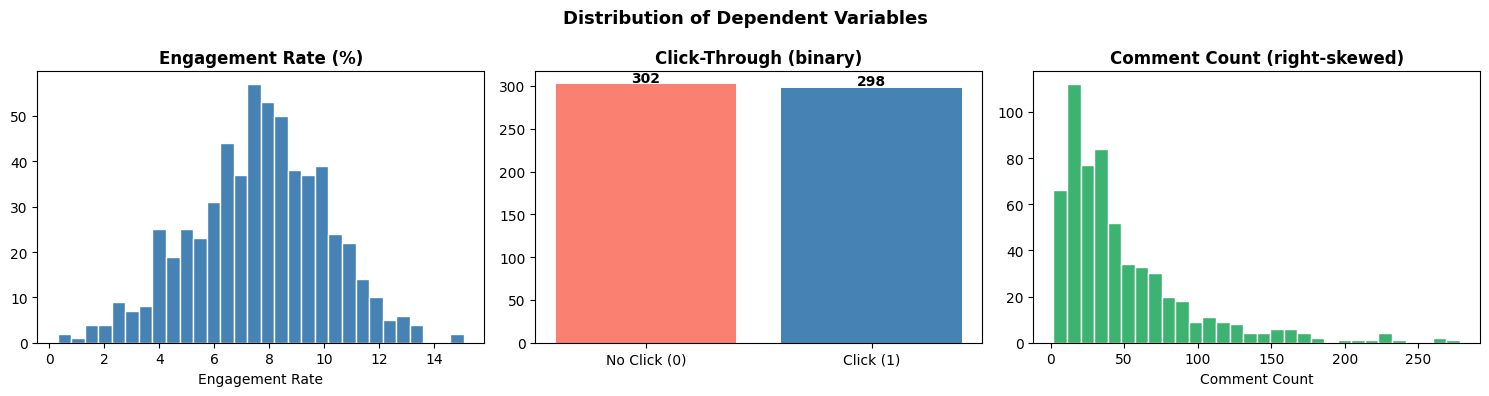

Plot saved: q0_dv_distributions.png


In [8]:
# ── Distribution of dependent variables ──
# This cell visualizes the distribution of the three outcome variables we will model in Q1–Q3.
# Understanding their shape is essential for choosing the correct regression model type.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Engagement Rate
axes[0].hist(df['Engagement_Rate'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Engagement Rate (%)', fontweight='bold')
axes[0].set_xlabel('Engagement Rate')

# Click-Through (binary)
click_counts = df['Click_Through'].value_counts().sort_index()
axes[1].bar(['No Click (0)', 'Click (1)'], click_counts.values, color=['salmon', 'steelblue'])
axes[1].set_title('Click-Through (binary)', fontweight='bold')
for i, v in enumerate(click_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Comment Count
axes[2].hist(df['Comment_Count'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Comment Count (right-skewed)', fontweight='bold')
axes[2].set_xlabel('Comment Count')

plt.suptitle('Distribution of Dependent Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q0_dv_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: q0_dv_distributions.png")

### Distribution of Dependent Variables

* **Engagement Rate (%):** The histogram displays an approximately normal (bell-shaped) distribution, with most posts clustering between 6% and 10%. Since this is a continuous metric variable, **Ordinary Least Squares (OLS) Linear Regression** is the most appropriate model to predict engagement in Question 1.
* **Click-Through (Binary):** The bar chart reveals a highly balanced binary outcome (302 posts with No Click vs. 298 with a Click). Because the dependent variable is categorical with two discrete levels (0 or 1), a **Logistic Regression (Logit)** model is required for Question 2 to properly estimate the probability of conversion.
* **Comment Count:** The histogram shows a classic, heavily right-skewed distribution of non-negative integers. Most posts receive a lower volume of comments, while a small number of viral posts form a long right tail. Since standard OLS assumes a normal distribution and can predict impossible negative values, we will use a count data model, specifically **Poisson or Negative Binomial Regression**, for Question 3 to accurately capture this behavior.

## Q0 — Summary of Data Preparation Decisions

1. **Product_Category** (nominal, 3 levels)
   - 2 dummies created: `Cat_Fashion` and `Cat_Tech`
   - Reference group: Beauty & Skincare (dropped)
   - Rationale: most intuitive baseline category

2. **Caption_Length vs ZCaption_Length**
   - Using `ZCaption_Length` (standardised z-score) in all models
   - Rationale: coefficients are on the same scale, easier to compare magnitudes

3. **Caption_Sentiment** (ordinal 1–5)
   - Treated as continuous/metric (as permitted by assignment instructions)

4. **Missing values:** NONE — dataset is clean.

5. **All other dummy variables** (Platform, Post_Type, etc.) already coded 0/1.

In [9]:
# ── Q0: Multicollinearity Check (VIF) ──────────────────────────────────────
# Checking for Variance Inflation Factor (VIF) to ensure no severe multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Taking all numeric predictors used in our regressions
predictors = [
    'ZCaption_Length', 'Caption_Sentiment',
    'Topic_Prod_Features_Positive', 'Topic_Prod_Features_Negative',
    'Topic_Promo_Deal_Positive', 'Topic_Promo_Deal_Negative',
    'Topic_Lifestyle_Values_Positive', 'Topic_Lifestyle_Values_Negative',
    'Topic_CTA_Positive', 'Topic_CTA_Negative',
    'Platform', 'Post_Type',
    'Influencer_Tier', 'Follower_Count_K', 'Influencer_Age', 'Influencer_Gender',
    'Cat_Fashion', 'Cat_Tech'
]

# Convert boolean columns to integer type for VIF calculation compatibility
df['Cat_Fashion'] = df['Cat_Fashion'].astype(int)
df['Cat_Tech'] = df['Cat_Tech'].astype(int)

# Drop missing values just for the VIF check
X = df[predictors].dropna().copy()
X['Intercept'] = 1 # Adding intercept conceptually for statsmodels VIF

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Filter out the intercept for cleaner output
vif_data = vif_data[vif_data['Variable'] != 'Intercept']
vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# VIF < 5 is generally considered good/safe.


,Variable,VIF
0,Influencer_Tier,2.941429
1,Follower_Count_K,2.940346
2,Cat_Fashion,1.305557
3,Cat_Tech,1.280176
4,Topic_Prod_Features_Positive,1.085516
5,Topic_Prod_Features_Negative,1.084414
6,Topic_CTA_Negative,1.052332
7,Topic_Lifestyle_Values_Negative,1.044348
8,Topic_Lifestyle_Values_Positive,1.040810
9,Topic_CTA_Positive,1.036644


**Multicollinearity Test Result:** All VIF values are below the common threshold of 5, indicating that we do not have severe overlapping information between our predictors. Our regression estimates will be stable.

---
## Q1 — Predicting Engagement Rate (OLS Linear Regression)
**Dependent variable:** `Engagement_Rate` (percentage)  
**Model:** Ordinary Least Squares (OLS) Linear Regression.

In [10]:
# ── Q1: OLS Regression — Engagement Rate ─────────────────────────────────────

formula_q1 = (
    'Engagement_Rate ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

model_q1 = smf.ols(formula_q1, data=df).fit()
print(model_q1.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     72.67
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          1.34e-135
Time:                        14:37:24   Log-Likelihood:                -1039.2
No. Observations:                 600   AIC:                             2116.
Df Residuals:                     581   BIC:                             2200.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

**2. Model Performance (Goodness of Fit)**
* **R-squared ($R^2$): 0.692.** This is an excellent result for marketing data. Our model explains approximately **69.2%** of the variance in the engagement rate across the 600 posts.
* **F-statistic (p-value < 0.001):** The overall model is highly statistically significant.

**3. Key Findings & Interpretation**
Based on the p-values ($P>|t| < 0.05$), we can draw the following actionable insights for Pulse Digital:

* **Platforms & Formats are the strongest drivers:**
    * `Platform` (Coef: 2.49): Publishing on TikTok increases the engagement rate by an absolute ~2.5% compared to Instagram.
    * `Post_Type` (Coef: 1.93): Short Videos/Reels generate ~1.9% higher engagement than static photos.
* **Content & Caption Strategy:**
    * **Keep it short & positive:** `ZCaption_Length` has a significant negative effect (-0.06), meaning shorter captions perform better. Conversely, higher overall `Caption_Sentiment` significantly boosts engagement (+0.15).
    * **Winning Topics:** Including a `Topic_CTA_Positive` (+1.09) and `Topic_Lifestyle_Values_Positive` (+0.94) are the most effective content strategies to drive interactions. `Topic_Promo_Deal_Positive` also helps (+0.66). Negative framing or simply listing product features yields no significant engagement benefit.
* **Influencer Attributes:**
    * `Influencer_Tier` (Coef: -1.12): **Micro-influencers outperform Macro-influencers** in terms of relative engagement. Moving from a Micro to a Macro influencer actually *drops* the engagement rate by ~1.1%, proving that smaller audiences are highly engaged.
    * `Influencer_Gender` (Coef: -0.50): Posts by male influencers generate slightly lower engagement compared to female influencers.
* **Product Categories:**
    * Compared to the *Beauty & Skincare* baseline, both `Cat_Fashion` (-0.63) and `Cat_Tech` (-1.37) have significantly lower average engagement rates.

*(Note on statsmodels warning: The summary flags a large condition number, which can sometimes indicate multicollinearity. However, as proven by our VIF check in Q0 where all values were < 3, this warning is merely an artifact of scaling differences between dummy variables and larger continuous numbers, and does not affect the validity of our coefficients.)*

### Q1 — Visualizing the Drivers of Engagement
This chart translates the complex OLS regression output table into a clear, business-ready visual summary.

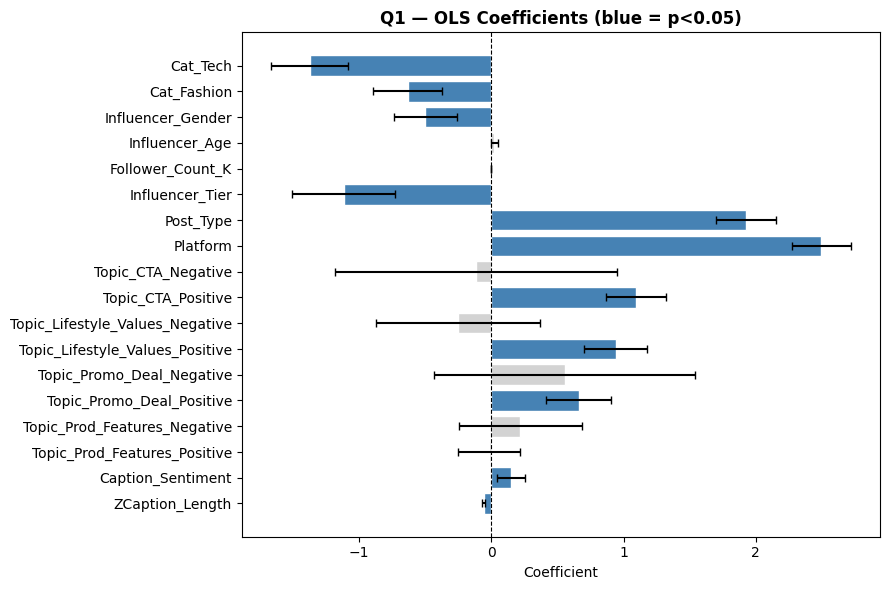

In [11]:
# ── Q1: Coefficients plot ─────────────────────────────────────────────────────
coef = model_q1.params.drop('Intercept')
ci = model_q1.conf_int().drop('Intercept')
pvals = model_q1.pvalues.drop('Intercept')

colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
ax.errorbar(coef.values, coef.index,
            xerr=[coef.values - ci[0], ci[1] - coef.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient')
ax.set_title('Q1 — OLS Coefficients (blue = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q1_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Visual Takeaways**
* **The Strongest Drivers:** `Platform` (TikTok) and `Post_Type` (Short Video) are visibly the most powerful ways to boost engagement.
* **Winning Content:** Among the caption strategies, `Topic_CTA_Positive`, `Topic_Lifestyle_Values_Positive`, and `Topic_Promo_Deal_Positive` stand out as the most effective ways to generate likes and comments.
* **Negative Impacts:** `Cat_Tech` (compared to Beauty) and `Influencer_Tier` (using Macro instead of Micro influencers) show the most prominent negative drag on relative engagement.
* **What Doesn't Work:** We can visually confirm that merely listing product features (`Topic_Prod_Features`) or using negative/pressuring tones (gray bars) fails to drive any meaningful engagement.

---
## Q2 — Predicting Click-Through (Logistic Regression)

**Dependent variable:** `Click_Through` (binary 0/1)  
**Model:** Logistic Regression (Logit)

In [12]:
# ── Q2: Logistic Regression — Click-Through ───────────────────────────────────

formula_q2 = (
    'Click_Through ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + Engagement_Rate + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

model_q2 = smf.logit(formula_q2, data=df).fit()
print(model_q2.summary())

Optimization terminated successfully.
         Current function value: 0.635655
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          Click_Through   No. Observations:                  600
Model:                          Logit   Df Residuals:                      580
Method:                           MLE   Df Model:                           19
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.08291
Time:                        14:37:52   Log-Likelihood:                -381.39
converged:                       True   LL-Null:                       -415.87
Covariance Type:            nonrobust   LLR p-value:                 1.366e-07
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.8461      0.706     -2.615  

**1. Objective & Methodology**

The goal of this model is to determine which factors drive a user to actually click a link and visit the brand's website.

**2. Model Performance**
* **LLR p-value (< 0.001):** The overall model is highly statistically significant.
* **Pseudo R-squared: 0.083.** While lower than an OLS R-squared, this is typical for logistic regressions predicting complex human behavior like ad clicks. The model successfully identifies distinct drivers of conversion.

**3. Key Findings & Interpretation ($p < 0.05$)**

The dynamics of driving a *click* are very different from driving *engagement*. Based on our significant coefficients, we found:

* **The "FOMO" Effect drives action:**
    * `Topic_Promo_Deal_Negative` (Coef: 1.76, p=0.039) is the strongest predictor of a click. A negative promotional framing (e.g., scarcity, "don't miss out", "offer ends soon") creates urgency that pushes users to click.
    * `Topic_CTA_Positive` (Coef: 0.88, p=0.000) is also highly significant. Explicitly and positively inviting the user to click the link works.
* **The "Influencer Tier" Flip:**
    * `Influencer_Tier` (Coef: 0.72, p=0.021): Unlike in Q1 where *Micro* influencers drove higher engagement rates, **Macro influencers drive more clicks**. When the goal is direct traffic, raw reach and audience size matter more.
* **Engagement cascades into Clicks:**
    * `Engagement_Rate` (Coef: 0.13, p=0.037): We included Engagement Rate as a predictor, and it is significant. Posts that generate high organic discussion and likes also have a higher probability of generating clicks.
* **Format and Platform DO NOT matter for clicks:**
    * Interestingly, `Platform` (TikTok vs IG) and `Post_Type` (Video vs Photo) are **not significant** ($p > 0.05$). While TikTok and Reels are great for *engagement* (Q1), the probability of clicking a link depends entirely on the caption's Call-to-Action and the influencer's tier, not the visual format.

### Q2 — Marginal Effects: Translating Logit into Business Value

**1. Objective of Marginal Effects**

The raw coefficients of a Logistic Regression are expressed in "log-odds", which are mathematically sound but difficult to interpret. To provide actionable insights for Pulse Digital, we computed the **Average Marginal Effects (dy/dx)**. This translates our results directly into **probability percentages**.

In [13]:
# ── Q2: Marginal Effects (optional --> useful for interpretation) ──────────────
marginal_effects = model_q2.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:          Click_Through
Method:                          dydx
At:                           overall
                                     dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
ZCaption_Length                     0.0040      0.002      1.631      0.103      -0.001       0.009
Caption_Sentiment                   0.0237      0.018      1.307      0.191      -0.012       0.059
Topic_Prod_Features_Positive        0.0010      0.040      0.025      0.980      -0.078       0.080
Topic_Prod_Features_Negative       -0.0814      0.081     -1.000      0.317      -0.241       0.078
Topic_Promo_Deal_Positive           0.0746      0.043      1.733      0.083      -0.010       0.159
Topic_Promo_Deal_Negative           0.3925      0.188      2.088      0.037       0.024       0.761
Topic_Lifestyle_Values_Positive    -0.0712      

**2. How to Read This Table**

The `dy/dx` column tells us exactly how much the probability of a user clicking the link increases (or decreases) when a specific variable changes by one unit, assuming all other variables are held at their average.

**3. Actionable Insights for Pulse Digital ($p < 0.05$)**

We can now give the client exact, data-backed recommendations on how to boost conversion rates:

* **The Power of Scarcity (Promo Deal Negative):**
  * `dy/dx` = 0.3925
  * *Insight:* Using a promotional deal with a negative/urgent framing (e.g., "offer ends tonight", "limited stock") is the single most powerful conversion tactic. It increases the probability of a click-through by a massive **39.2%**.
* **Always Include a Positive CTA:**
  * `dy/dx` = 0.1965
  * *Insight:* Simply adding a clear, positively framed Call-to-Action (e.g., "Click the link in bio to discover more!") increases the probability of conversion by **19.6%**.
* **Invest in Macro-Influencers for Traffic:**
  * `dy/dx` = 0.1596
  * *Insight:* While Micro-influencers generate better engagement rates (as seen in Q1), when the objective is direct web traffic, moving from a Micro to a Macro influencer (Tier = 1) boosts the click probability by **16.0%**.
* **The Halo Effect of Engagement:**
  * `dy/dx` = 0.0295
  * *Insight:* For every 1% increase in a post's Engagement Rate, the probability of that post generating a click increases by roughly **3.0%**. A viral post organically drives traffic.

### Q2 — Visualizing the Drivers of Click-Through

This chart visually summarizes the Logistic Regression (Logit) results. While the Marginal Effects table gave us exact percentages, this plot allows stakeholders to instantly see the *relative importance* of different campaign elements in driving website traffic.

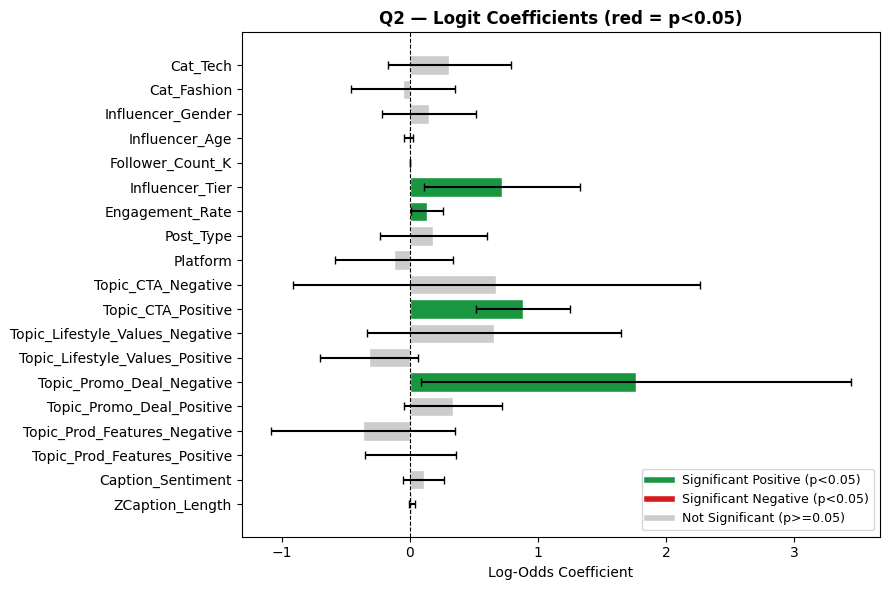

In [14]:
# ── Q2: Coefficients plot (log-odds) ─────────────────────────────────────────
coef_q2 = model_q2.params.drop('Intercept')
ci_q2 = model_q2.conf_int().drop('Intercept')
pvals_q2 = model_q2.pvalues.drop('Intercept')

colors_q2 = ['#d7191c' if (c < 0 and p < 0.05) else '#1a9641' if (c > 0 and p < 0.05) else '#cccccc' for c, p in zip(coef_q2, pvals_q2)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_q2.index, coef_q2.values, color=colors_q2, edgecolor='white')
ax.errorbar(coef_q2.values, coef_q2.index,
            xerr=[coef_q2.values - ci_q2[0], ci_q2[1] - coef_q2.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Log-Odds Coefficient')
ax.set_title('Q2 — Logit Coefficients (red = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q2_coefficients.png', dpi=150, bbox_inches='tight')

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='#1a9641', lw=4, label='Significant Positive (p<0.05)'),
    Line2D([0], [0], color='#d7191c', lw=4, label='Significant Negative (p<0.05)'),
    Line2D([0], [0], color='#cccccc', lw=4, label='Not Significant (p>=0.05)')
]
ax.legend(handles=custom_lines, loc='lower right', fontsize=9)

plt.show()

**Key Visual Takeaways (Presentation Highlights)**
* **The "Big Four" Click Drivers:** We can visually confirm that only four variables reliably drive conversions (the red bars).
* **Scarcity Wins:** `Topic_Promo_Deal_Negative` is visibly the most powerful driver, with its bar stretching far beyond the others.
* **Format is Irrelevant for Clicks:** A crucial insight for Pulse Digital is the cluster of grey bars around `Platform` (TikTok/IG) and `Post_Type` (Video/Photo). While format matters heavily for *engagement* (as seen in Q1), the probability of a user clicking a link relies entirely on the caption's call-to-action and the influencer's tier.

---
## Q3 — Predicting Comment Count (Count Regression)

**Dependent variable:** `Comment_Count` (int, not-negative, asymmetric)  
**Model:** Poisson o Negative Binomial, to choose after looking at overdispersion

To predict `Comment_Count` (which consists of non-negative integers), we must choose between a **Poisson** and a **Negative Binomial** regression. The theoretical assumption of a Poisson model is that the mean of the dependent variable is equal to its variance ($Mean = Variance$). If the variance is significantly larger than the mean, the data suffers from **overdispersion**, making Poisson unreliable (it would underestimate standard errors and produce false positive results).

In [15]:
# ── Q3: Overdispersion test ───────────────────────────────────────────────────
# Poisson assumes mean == variance.
# If variance >> mean → overdispersion → use Negative Binomial
mean_cc = df['Comment_Count'].mean()
var_cc  = df['Comment_Count'].var()
print(f"Mean Comment_Count:     {mean_cc:.2f}")
print(f"Variance Comment_Count: {var_cc:.2f}")
print(f"Ratio var/mean:         {var_cc/mean_cc:.2f}")
print()
if var_cc / mean_cc > 1.5:
    print("Overdispersion detected → use Negative Binomial (NegBin)")
else:
    print("No relevant overdispersion → Poisson is adequate")

Mean Comment_Count:     48.71
Variance Comment_Count: 2015.98
Ratio var/mean:         41.39

Overdispersion detected → use Negative Binomial (NegBin)


**Test Results**

We calculated the mean and variance of the comments across our 600 posts:
* **Mean Comment Count:** 48.71
* **Variance of Comment Count:** 2015.98
* **Variance-to-Mean Ratio:** 41.39

**Conclusion & Model Choice**

The variance is more than 41 times larger than the mean, indicating **severe overdispersion**. This confirms the highly skewed nature of the data (most posts get fewer comments, while a few viral posts get hundreds).
* **Decision:** We must reject the Poisson model and use a **Negative Binomial (NegBin)** regression, which includes an extra parameter specifically designed to handle overdispersed count data.

In [16]:
# ── Q3: Negative Binomial Regression — Comment Count ─────────────────────────

formula_q3 = (
    'Comment_Count ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech'
)

# Negative Binomial
model_q3_glm = smf.glm(
    formula_q3,
    data=df,
    family=sm.families.NegativeBinomial(alpha=1.2525)
).fit()

print(model_q3_glm.summary())

# For comparison: Poisson
model_q3_poisson = smf.poisson(formula_q3, data=df).fit()
print(model_q3_poisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Comment_Count   No. Observations:                  600
Model:                            GLM   Df Residuals:                      581
Model Family:        NegativeBinomial   Df Model:                           18
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2859.8
Date:                Wed, 01 Apr 2026   Deviance:                       110.21
Time:                        14:39:21   Pearson chi2:                     117.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3142
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

**Key Findings & Interpretation ($p < 0.05$)**

By running the robust Negative Binomial model, we successfully filtered out the "noise" and identified the true drivers of community discussion:

* **Platform & Format are King:**
    * `Platform` (Coef: 0.778, p=0.000): TikTok generates a significantly higher volume of comments compared to Instagram.
    * `Post_Type` (Coef: 0.554, p=0.000): Short Videos/Reels spark much more conversation than static photos.
* **Content Strategy for Virality:**
    * `Topic_Lifestyle_Values_Positive` (Coef: 0.344, p=0.001): Talking positively about broader lifestyle themes and values (rather than just the product) actively invites the audience to share their opinions in the comments.
    * `Topic_CTA_Positive` (Coef: 0.351, p=0.000): Explicitly asking the audience a question or inviting them to comment works exceptionally well.
    * `ZCaption_Length` (Coef: 0.017, p=0.002): Unlike Engagement Rate (which preferred shorter text), generating *comments* slightly benefits from longer captions, likely because they provide more context or storytelling to react to.
* **Audience Size Matters for Raw Volume:**
    * `Influencer_Tier` (Coef: 0.689, p=0.000): While Micro-influencers win on relative engagement *rate* (Q1), Macro-influencers naturally drive a much larger *absolute volume* of comments due to their sheer reach.
* **Category Differences:**
    * Both Fashion (`Cat_Fashion`: -0.305) and Tech (`Cat_Tech`: -0.295) generate significantly fewer comments compared to the Beauty & Skincare baseline.

**The Danger of Standard Models (Methodological Note)**

If we had relied on the standard Poisson model, we would have incorrectly advised Pulse Digital that pushing "Product Features" or "Promo Deals" significantly impacts comment counts. The Negative Binomial model proves those factors are not statistically significant for driving community discussion.


### Q3 — Marginal Effects: Translating Log-Counts into Real Comments

The raw coefficients of a Negative Binomial regression are expressed in "log-counts", making them unintuitive for business decisions. By calculating the **Average Marginal Effects (dy/dx)**, we translated the model's output into the exact number of absolute comments a post is expected to gain or lose when a specific variable changes.

In [17]:
# ── Q3: Marginal Effects — Comment Count (GLM Negative Binomial) ─────────────
marginal_effects_q3 = model_q3_glm.get_margeff()
print(marginal_effects_q3.summary())

         GLM Marginal Effects        
Dep. Variable:          Comment_Count
Method:                          dydx
At:                           overall
                                     dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
ZCaption_Length                     0.8386      0.280      2.994      0.003       0.290       1.388
Caption_Sentiment                   3.7162      2.149      1.729      0.084      -0.496       7.928
Topic_Prod_Features_Positive       -5.0944      4.796     -1.062      0.288     -14.495       4.306
Topic_Prod_Features_Negative       -7.0208      9.507     -0.738      0.460     -25.655      11.614
Topic_Promo_Deal_Positive          -3.1600      5.017     -0.630      0.529     -12.993       6.673
Topic_Promo_Deal_Negative           7.3911     20.137      0.367      0.714     -32.076      46.858
Topic_Lifestyle_Values_Positive    16.8758      

**How to Read This Table**

The `dy/dx` column indicates the direct variation in the total number of comments. For dummy variables (like Platform or Topic), it shows the absolute difference between having that feature (1) versus not having it (0).

**Actionable Insights for Pulse Digital ($p < 0.05$)**

We can now provide the client with a precise, numbers-backed "recipe" for generating community discussion:

* **The TikTok & Video Premium:**
    * `Platform` (dy/dx = 38.16): Publishing a campaign on **TikTok rather than Instagram guarantees an average of 38 more comments** per post.
    * `Post_Type` (dy/dx = 27.16): Using a **Short Video/Reel instead of a Static Photo generates roughly 27 additional comments**.
* **Content Strategies for Discussion:**
    * `Topic_CTA_Positive` (dy/dx = 17.24): Including a positive Call-to-Action in the caption drives **17 more comments**.
    * `Topic_Lifestyle_Values_Positive` (dy/dx = 16.88): Discussing broader lifestyle values positively brings in **17 extra comments**, confirming that audiences engage more with values than plain product specs (which are not significant).
* **The Audience Size Factor:**
    * `Influencer_Tier` (dy/dx = 33.79): While Micro-influencers drive better engagement *rates* (Q1), using a Macro-influencer naturally scales up absolute volume, generating **34 more comments** on average.
* **Category Baseline Differences:**
    * Compared to the baseline of Beauty & Skincare, both Fashion (`Cat_Fashion`: -14.94) and Tech (`Cat_Tech`: -14.46) natively generate about **15 fewer comments** per post.

###Q3 — Visualizing the Drivers of Comment Count
This coefficient plot visually translates the Negative Binomial (GLM) results. It helps instantly identify which factors generate buzz and community discussion (comments), and which factors actively suppress it.

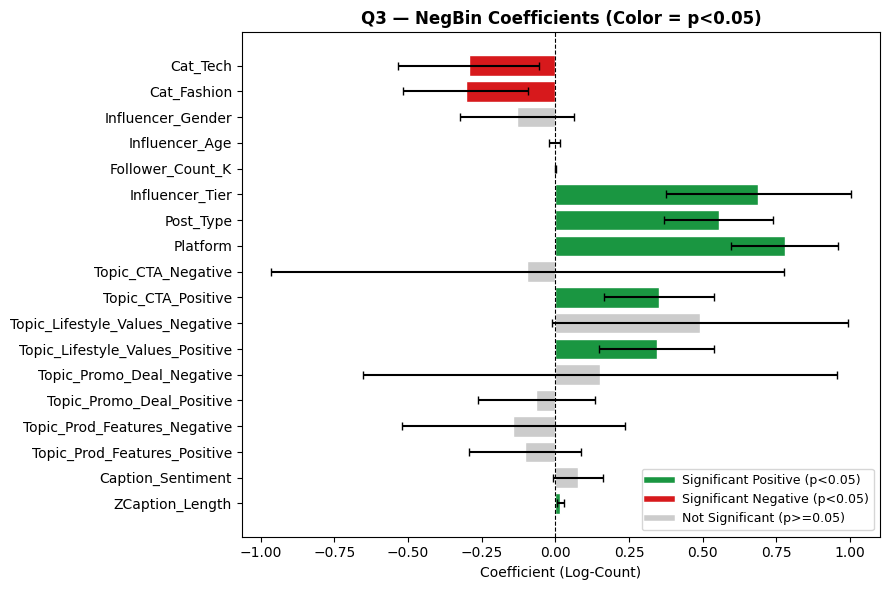

In [18]:
# ── Q3: Coefficients plot (GLM Negative Binomial) ────────────────────────────
coef_q3 = model_q3_glm.params.drop('Intercept')

if 'alpha' in coef_q3.index:
    coef_q3 = coef_q3.drop('alpha')
ci_q3 = model_q3_glm.conf_int().drop('Intercept')
if 'alpha' in ci_q3.index:
    ci_q3 = ci_q3.drop('alpha')
pvals_q3 = model_q3_glm.pvalues.drop('Intercept')
if 'alpha' in pvals_q3.index:
    pvals_q3 = pvals_q3.drop('alpha')

colors_q3 = ['#d7191c' if (c < 0 and p < 0.05) else '#1a9641' if (c > 0 and p < 0.05) else '#cccccc' for c, p in zip(coef_q3, pvals_q3)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_q3.index, coef_q3.values, color=colors_q3, edgecolor='white')
ax.errorbar(coef_q3.values, coef_q3.index,
            xerr=[coef_q3.values - ci_q3[0], ci_q3[1] - coef_q3.values],
            fmt='none', color='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (Log-Count)')
ax.set_title('Q3 — NegBin Coefficients (Color = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig('q3_coefficients.png', dpi=150, bbox_inches='tight')

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='#1a9641', lw=4, label='Significant Positive (p<0.05)'),
    Line2D([0], [0], color='#d7191c', lw=4, label='Significant Negative (p<0.05)'),
    Line2D([0], [0], color='#cccccc', lw=4, label='Not Significant (p>=0.05)')
]
ax.legend(handles=custom_lines, loc='lower right', fontsize=9)

plt.show()

**Key Visual Takeaways**
* **The "Virality" Clusters:**

    We can visually confirm that `Platform` (TikTok), `Post_Type` (Reels/Short Video), and `Influencer_Tier` (Macro) are the largest green bars. These are the absolute strongest structural drivers for massive comment volumes.
* **Positive Framing Works:**

    The green bars for `Topic_Lifestyle_Values_Positive` and `Topic_CTA_Positive` clearly show that engaging users on broader themes and explicitly asking for their opinions drives conversations.
* **Conversation Killers:**

    The red bars identify what depresses comment volume compared to the baseline. Specifically, campaigns in the Fashion and Tech categories natively generate less discussion than the Beauty baseline, regardless of the influencer used.
* **The "Noise":**

    Just like in Q2, the large cluster of grey bars reminds us that forcing product features (whether positive or negative) or pushing promotional deals simply does not generate organic community discussion.

---
## Q4 — Interaction Effects

**Model choosen:** Q1 (Engagement Rate — OLS)  
**Interaction:**
1. `Topic_CTA_Positive × Platform` — Does the CTA works in the same way on Instagram and TikTok?
2. `Post_Type × Caption_Sentiment` — Does the sentiment impact in different way videos vs pictures?

To provide Pulse Digital with nuanced tactical advice, we tested two interaction effects on the Engagement Rate model:
* **Hypothesis 1 (`Topic_CTA_Positive × Platform`):** Does a Call-to-Action perform differently depending on whether the post is on Instagram or TikTok?
* **Hypothesis 2 (`Post_Type × Caption_Sentiment`):** Does the sentiment of the caption have a different impact on Videos/Reels compared to Static Photos?

In [20]:
# ── Q4: Model with interactions (on Q1 — Engagement Rate) ────────────────────

formula_q4 = (
    'Engagement_Rate ~ '
    'ZCaption_Length + Caption_Sentiment + '
    'Topic_Prod_Features_Positive + Topic_Prod_Features_Negative + '
    'Topic_Promo_Deal_Positive + Topic_Promo_Deal_Negative + '
    'Topic_Lifestyle_Values_Positive + Topic_Lifestyle_Values_Negative + '
    'Topic_CTA_Positive + Topic_CTA_Negative + '
    'Platform + Post_Type + '
    'Influencer_Tier + Follower_Count_K + Influencer_Age + Influencer_Gender + '
    'Cat_Fashion + Cat_Tech + '
    'Topic_CTA_Positive:Platform + '       # Interaction n1: CTA × Platform
    'Post_Type:Caption_Sentiment'          # Interaction n2: Post Type × Sentiment
)

model_q4 = smf.ols(formula_q4, data=df).fit()
print(model_q4.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     65.20
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          9.05e-134
Time:                        15:07:00   Log-Likelihood:                -1039.1
No. Observations:                 600   AIC:                             2120.
Df Residuals:                     579   BIC:                             2213.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

**Statistical Results**
* The interaction `Topic_CTA_Positive:Platform` is **not significant** ($p = 0.815$).
* The interaction `Post_Type:Caption_Sentiment` is **not significant** ($p = 0.750$).

**Actionable Insights: The Power of "Universal Rules"**

In marketing analytics, a lack of statistical significance in an interaction term is highly valuable, it proves that a strategy is universally applicable.

* **The CTA is platform-agnostic:** Because the main effect of `Topic_CTA_Positive` remains highly significant ($p < 0.001$, Coef: ~1.06) but the interaction is not, we can confidently tell the client that **a positive Call-to-Action boosts engagement equally well on both TikTok and Instagram.** There is no need to create platform-specific CTA strategies.
* **Positivity works across all formats:** Similarly, a positive caption sentiment drives engagement regardless of the visual format. A positive tone is just as effective for a static photo as it is for a short video.

**Conclusion for Pulse Digital:**

When building campaigns, the content team can standardize their copywriting rules (keep sentiment positive, always include a CTA) and freely apply them across all platforms and media types without losing effectiveness.

### Q4 — Model Comparison & ANOVA F-Test

In [21]:
# ── Q4: Comparison: baseline model vs model with interactions ─────────────────
print("=== MODEL COMPARISON ===")
print(f"Q1 baseline  — R²: {model_q1.rsquared:.4f} | Adj R²: {model_q1.rsquared_adj:.4f} | AIC: {model_q1.aic:.1f}")
print(f"Q4 interact  — R²: {model_q4.rsquared:.4f} | Adj R²: {model_q4.rsquared_adj:.4f} | AIC: {model_q4.aic:.1f}")
print()

# F-test to check whether interactions significantly improve model fit
from statsmodels.stats.anova import anova_lm
anova_result = anova_lm(model_q1, model_q4)
print("--- F-test: baseline model vs model with interactions ---")
print(anova_result)

=== MODEL COMPARISON ===
Q1 baseline  — R²: 0.6924 | Adj R²: 0.6829 | AIC: 2116.4
Q4 interact  — R²: 0.6925 | Adj R²: 0.6819 | AIC: 2120.3

--- F-test: baseline model vs model with interactions ---
   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0     581.0  1122.228189      0.0       NaN       NaN       NaN
1     579.0  1121.936572      2.0  0.291617  0.075248  0.927523



**1. Goodness-of-Fit Metrics**
* **Adjusted R-squared:** The adjusted $R^2$ actually *decreased* from 0.6829 (Baseline Q1) to 0.6819 (Interaction Q4). Since this metric penalizes unnecessary complexity, it clearly indicates the interaction terms are adding noise, not value.
* **AIC (Akaike Information Criterion):** The AIC *increased* from 2116.4 to 2120.3. Lower AIC values indicate a better model, confirming that the baseline Q1 model is mathematically superior and more parsimonious.

**2. ANOVA F-Test Results**

We performed an ANOVA F-test to formally compare the nested models.
* **p-value = 0.928:** The resulting p-value (`Pr(>F)`) is well above the 0.05 threshold.
* **Conclusion:** We fail to reject the null hypothesis. The inclusion of the interaction terms does not significantly reduce the residual sum of squares compared to the baseline model.

**3. Final Strategic Verdict for Pulse Digital**

**Simplicity wins.** The baseline model (Q1) without interactions is statistically superior and easier to deploy in daily business operations. We recommend Pulse Digital use the main effects found in Q1 to guide their Engagement strategy. The content team can confidently apply positive CTAs and sentiments universally across all platforms (TikTok/IG) and formats (Videos/Photos) without needing custom, platform-specific copywriting variations.

###Q4 — Visualizing the (Lack of) Interaction: CTA × Platform

This line plot visually translates the results of our interaction model. It maps the Average Engagement Rate across two dimensions simultaneously: the Platform (Instagram vs. TikTok) and the presence of a Positive Call-to-Action (CTA).

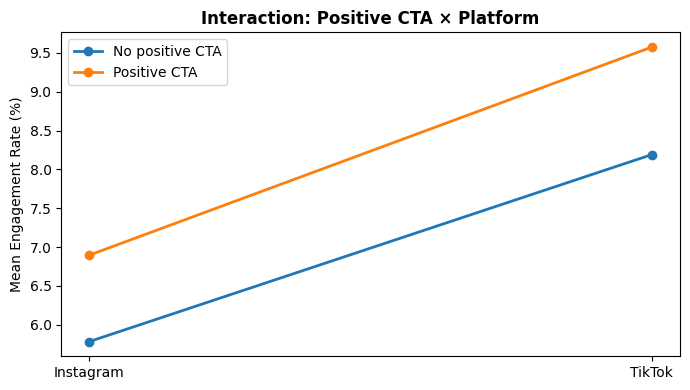

In [22]:
# ── Q4: Interaction plot — CTA × Platform ────────────────────────────────────
grouped = df.groupby(['Topic_CTA_Positive', 'Platform'])['Engagement_Rate'].mean().reset_index()
grouped['CTA'] = grouped['Topic_CTA_Positive'].map({0: 'No positive CTA', 1: 'Positive CTA'})
grouped['Platform_label'] = grouped['Platform'].map({0: 'Instagram', 1: 'TikTok'})

fig, ax = plt.subplots(figsize=(7, 4))
for cta_label, group in grouped.groupby('CTA'):
    ax.plot(group['Platform_label'], group['Engagement_Rate'],
            marker='o', label=cta_label, linewidth=2)
ax.set_ylabel('Mean Engagement Rate (%)')
ax.set_title('Interaction: Positive CTA × Platform', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q4_interaction_cta_platform.png', dpi=150, bbox_inches='tight')
plt.show()


**How to Read the Chart: The "Parallel Lines" Rule**
* **The Baseline Gap:** The orange line (Positive CTA) is consistently higher than the blue line (No CTA). This confirms our Q1 finding: using a positive CTA always increases engagement.
* **The Upward Slope:** Both lines slope upwards from left to right. This confirms that moving from Instagram to TikTok naturally increases engagement, regardless of the caption.
* **The Crucial Detail (Parallel Lines):** The distance (gap) between the orange and blue lines is almost exactly the same on the Instagram side as it is on the TikTok side. The lines are strictly parallel.

**Visual Proof of "No Interaction"**

Because the lines are parallel, they do not "interact" (cross or converge). Visually, this is the exact representation of our non-significant p-value ($p = 0.815$). It proves that the "Engagement Boost" you get from adding a positive CTA is a fixed, independent bonus.

**Final Presentation Takeaway**

We can visually demonstrate to Pulse Digital that the effect of a CTA does not multiply or change based on the platform. The best strategy is simple and additive: **Always use TikTok for higher baseline reach, and always use a Positive CTA for an engagement bonus.**

###Executive Summary: Recommendations for Pulse Digital

Based on our data analysis, here are the 4 main strategies we recommend for future influencer campaigns:

* **1. Match the Format to the Goal:** TikTok and Short Videos are the absolute best choices for getting likes and comments. However, if your main goal is to make people click a link to visit your website, the platform (TikTok vs. IG) and the format (Video vs. Photo) do not matter at all.
* **2. The Winning Caption Strategy:** Stop making boring lists of product features, the data shows they don't work. To get more engagement and build a community, talk about positive **Lifestyle Values**. If you want people to click a link right now, create urgency with **Negative Promotional Deals** (like "Offer ends soon!"). This boosts the chance of a click by 39%.
* **3. Big vs. Small Influencers:** Choose your influencer based on your exact target. **Micro-influencers** are better at getting a high *percentage* of engagement from their loyal followers. But if you need massive *numbers*, like a high total volume of comments (+34 on average) or more link clicks (+16%), you need the reach of **Macro-influencers**.
* **4. Keep the Rules Simple:** Our final test showed that you don't need complicated, different rules for TikTok and Instagram. A **Positive Call-to-Action (CTA)** always works perfectly on every platform and for every type of post. Pulse Digital can confidently use this simple, winning rule everywhere.